### Week 7 — NLP Text Classification
- Build a model to classify text.

| Support Ticket | Category |
|-------------------------|-------------------|
| Cannot login | Login issue |
| Upload failed | Upload issue |
| Network timeout | Network issue |
| Permission denied | Permission issue |

  
  **Pipeline:**
1. Load The Data|set
2. Text preprocessing (clean the raw text)
3. TF-IDF vectorization (convert text → numbers)
4. Train/test split
5. Train a classifier
6. Evaluate performance
7. Predict on brand-new, unseen tickets

### 1.Import Libraries:

In [12]:
import pandas as pd
import numpy as np
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

### 2.Loading The Dataset:

In [13]:
df = pd.read_csv('tickets.csv')
df.head()

,text,category
0,Cannot login,Login issue
1,Unable to log in to my account,Login issue
2,Login page keeps failing,Login issue
3,Forgot password and cannot sign in,Login issue
4,Incorrect username or password error,Login issue


In [14]:
df['category'].value_counts()

category
Permission issue    14
Login issue         12
Upload issue        12
Network issue       12
Name: count, dtype: int64

### 3.Text Preprocessing:

In [15]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

lemmatizer = WordNetLemmatizer()
corpus = []

for i in range(len(df)):
    review = re.sub('[^a-zA-Z]',' ',df['text'][i])
    review = review.lower()
    review = review.split()
    review = [lemmatizer.lemmatize(word,pos='v') for word in review  if word not in set(stopwords.words('english'))]
    review=' '.join(review)
    corpus.append(review)
     
df['clean_text'] = corpus
df[['text', 'clean_text', 'category']].head()

,text,clean_text,category
0,Cannot login,cannot login,Login issue
1,Unable to log in to my account,unable log account,Login issue
2,Login page keeps failing,login page keep fail,Login issue
3,Forgot password and cannot sign in,forget password cannot sign,Login issue
4,Incorrect username or password error,incorrect username password error,Login issue


##  4.TF-IDF Vectorization

Converts cleaned text into numeric feature vectors.

In [16]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['clean_text'])
y = df['category']

print('Feature matrix shape:',X.shape)
print('Vocabulary size:',len(vectorizer.vocabulary_))

tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df.head()

Feature matrix shape: (50, 106)
Vocabulary size: 106


,accept,access,account,action,admin,allow,app,application,attachment,attempt,...,unreachable,unstable,upload,use,user,username,view,vpn,wifi,work
0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0
1,0.0,0.0,0.547362,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0
2,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0
3,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0
4,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.56651,0.0,0.0,0.0,0.0


### 5.Train/Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42,stratify=y)
print('Train Data Size:',X_train.shape[0])
print('Test Data Size:',X_test.shape[0])

Train Data Size: 40
Test Data Size: 10


### 6.Train The Classifier Model

#### Navie Bayes:

In [18]:
nb_model = MultinomialNB()
nb_model.fit(X_train,y_train)
nb_pred = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

print(classification_report(y_test, nb_pred))


Naive Bayes Accuracy: 0.9
                  precision    recall  f1-score   support

     Login issue       1.00      1.00      1.00         2
   Network issue       1.00      0.50      0.67         2
Permission issue       0.75      1.00      0.86         3
    Upload issue       1.00      1.00      1.00         3

        accuracy                           0.90        10
       macro avg       0.94      0.88      0.88        10
    weighted avg       0.93      0.90      0.89        10



#### Logistic Regression:

In [19]:
lr_model = LogisticRegression()
lr_model.fit(X_train,y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.9
                  precision    recall  f1-score   support

     Login issue       1.00      1.00      1.00         2
   Network issue       1.00      0.50      0.67         2
Permission issue       0.75      1.00      0.86         3
    Upload issue       1.00      1.00      1.00         3

        accuracy                           0.90        10
       macro avg       0.94      0.88      0.88        10
    weighted avg       0.93      0.90      0.89        10



### Confusion Matrix:

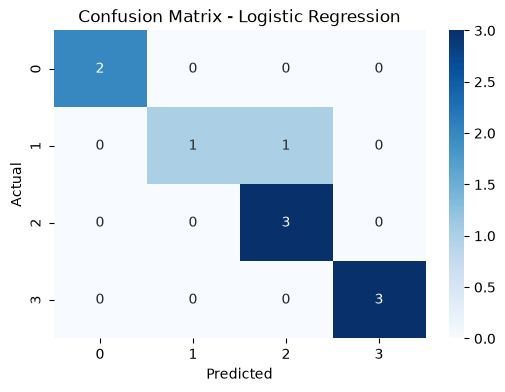

In [20]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 7.Predict Unseen Tickets:


In [25]:
def predict_category(text, model=lr_model):

    review = re.sub('[^a-zA-Z]', ' ', text)
    review = review.lower()
    review = review.split()

    review = [
        lemmatizer.lemmatize(word, pos='v')
        for word in review
        if word not in set(stopwords.words('english'))
    ]

    review = ' '.join(review)

    vector = vectorizer.transform([review])

    prediction = model.predict(vector)[0]

    confidence = model.predict_proba(vector).max()

    return prediction, confidence

In [26]:
new_df = pd.read_csv("unseen_tickets.csv")

predictions = []
confidences = []

for text in new_df["text"]:

    category, confidence = predict_category(text)

    predictions.append(category)
    confidences.append(round(confidence, 2))
result_df = pd.DataFrame({
"Support Ticket": new_df["text"],
"Predicted Category": predictions,
"Confidence": confidences
})
result_df

,Support Ticket,Predicted Category,Confidence
0,Unable to sign into the portal,Login issue,0.38
1,Authentication failed while logging in,Login issue,0.44
2,Password reset link is not working,Login issue,0.37
3,Login verification code not received,Login issue,0.58
4,Getting stuck on sign in screen,Login issue,0.28
5,Cannot authenticate my account,Login issue,0.44
6,User account locked unexpectedly,Login issue,0.33
7,Login process keeps loading forever,Login issue,0.40
8,Unable to access dashboard after login,Login issue,0.44
9,Receiving invalid credentials message,Login issue,0.35
